In [1]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 48.3 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=bfe87faecc8c046300d1080353a85232decd0b8193a532bc42c92990a9c5b1cf
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


LOs primeros pasos que haremos serán:

1.  **Montar Google Drive**: Hemos montado Google Drive para poder acceder a los archivos almacenados en la nube.

    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    ```

2.  **Definir Rutas de Archivos**: Hemos establecido las rutas base y específicas para las imágenes y el archivo de metadatos dentro de Google Drive.

    ```python
    BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
    PATH_IMAGES = f"{BASE_PATH}/images"
    PATH_METADATA = f"{BASE_PATH}/metadata.csv"

    print(PATH_IMAGES)
    print(PATH_METADATA)
    ```

3.  **Cargar Metadatos**: Hemos cargado el archivo `metadata.csv` en un DataFrame de pandas y mostrado las primeras filas para una inspección rápida de los datos.

    ```python
    import pandas as pd
    import os

    df = pd.read_csv(PATH_METADATA)
    df.head()
    ```

4.  **Listar Contenido del Directorio**: Hemos verificado el contenido del directorio `proccessed_data` para confirmar la presencia de los archivos.

    ```python
    !ls "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
    ```

In [15]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata_augmented.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv


In [16]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()

num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


In [ ]:
import pandas as pd
import os

# Cargar metadata
df = pd.read_csv(PATH_METADATA)

# Crear nueva ruta hacia PNG
df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

# Mostrar primeras filas con información relevante
print(df[["img_name", "file_path"]].head())

# Verificar si las rutas son válidas
print("\nVerificando existencia de archivos PNG:")

for i in range(5):  # probar las 5 primeras rutas
    fp = df.loc[i, "file_path"]
    exists = os.path.exists(fp)
    print(f"{fp} → {'OK' if exists else 'NO ENCONTRADO'}")

# Contar positivos y negativos
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("\nResumen:")
print("Negativos:", num_neg)
print("Positivos:", num_pos)


    img_name                                          file_path
0  n0239.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
1  n0342.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
2  n0996.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
3  n0418.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
4  n0538.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...

Verificando existencia de archivos PNG:
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0239.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0996.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0418.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0538.png → OK

Resumen:
Negativos: 3748
Positivos: 4427


In [17]:
from torch.utils.data import Dataset, DataLoader
class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        self.df = df.copy()
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

        # UNA entrada por imagen
        self.images = self.df["file_path"].unique().tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]

        # Cargar imagen
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # 3 canales
        img3 = np.stack([img, img, img], axis=0)

        # Todas las anotaciones de esa imagen
        rows = self.df[self.df["file_path"] == path]

        boxes = []
        labels = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        return torch.tensor(img3, dtype=torch.float32), target

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

def show_png_with_boxes(df, idx):
    # Obtener ruta y nombre del archivo
    path = df.loc[idx, "file_path"]
    img_name = df.loc[idx, "img_name"]
    print("Mostrando:", path)

    # Cargar imagen PNG
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("ERROR: No se pudo cargar la imagen")
        return

    # Normalización para visualización
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Obtener todas las anotaciones de esta imagen
    rows = df[df["file_path"] == path]

    boxes = []
    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = float(r["x"])
            y1 = float(r["y"])
            x2 = x1 + float(r["width"])
            y2 = y1 + float(r["height"])
            boxes.append((x1, y1, x2, y2))

    # ------------------------------
    #  VISUALIZACIÓN
    # ------------------------------
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{img_name} — {len(boxes)} nódulos", fontsize=14)

    # Dibujar cada bounding box
    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.axis("off")
    plt.show()
show_png_with_boxes(df, 1)

In [18]:
import cv2
import numpy as np
import torch
dataset = Node21DetectionDatasetPNG(df)

img, target = dataset[1]

print(img.shape)
print(target)

torch.Size([3, 1024, 1024])
{'boxes': tensor([[223., 642., 250., 682.]]), 'labels': tensor([1]), 'area': tensor([1080.]), 'iscrowd': tensor([0]), 'image_id': tensor([1])}


In [19]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets

# 2. Split
from sklearn.model_selection import train_test_split

images = df["file_path"].unique()

train_imgs, val_imgs = train_test_split(
    images, test_size=0.2, random_state=42
)

train_df = df[df["file_path"].isin(train_imgs)]
val_df   = df[df["file_path"].isin(val_imgs)]

# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

In [20]:
for imgs, targets in train_loader:
    print("Batch size:", len(imgs))
    print("Image shape:", imgs[0].shape)
    print("Targets:", targets[0])
    break

Batch size: 2
Image shape: torch.Size([3, 1024, 1024])
Targets: {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'area': tensor([]), 'iscrowd': tensor([], dtype=torch.int64), 'image_id': tensor([1113])}


In [22]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/fastercnn50_vindr.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Crear modelo base
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

# Cargar pesos VinDR
state_dict = torch.load(MODEL_PATH, map_location=device)

# Eliminar head VinDR (15 clases)
keys_to_remove = [
    "roi_heads.box_predictor.cls_score.weight",
    "roi_heads.box_predictor.cls_score.bias",
    "roi_heads.box_predictor.bbox_pred.weight",
    "roi_heads.box_predictor.bbox_pred.bias",
]

for k in keys_to_remove:
    if k in state_dict:
        del state_dict[k]

model.load_state_dict(state_dict, strict=False)


# Congelar todo el backbone primero
for param in model.backbone.body.parameters():
    param.requires_grad = False

# Descongelar layer4 (capas más profundas)
for name, param in model.backbone.body.named_parameters():
    if name.startswith("layer4"):
        param.requires_grad = True

# Dejar FPN entrenable
for name, param in model.backbone.named_parameters():
    if "fpn" in name:
        param.requires_grad = True

# Head Node21 (2 clases)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Device + train
model.to(device)
model.train()

print("Modelo Faster R-CNN VinDR listo para entrenamiento (layer4 + FPN entrenables).")


Modelo Faster R-CNN VinDR listo para entrenamiento (layer4 + FPN entrenables).


In [23]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    loop = tqdm(loader, desc="Entrenando", leave=True)

    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward + cálculo de pérdidas
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        # --- Mejora 1: protección frente a NaNs / Infs ---
        if not torch.isfinite(loss):
            print("Loss no finita detectada, batch omitido")
            continue

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # --- Mejora 2: mostrar pérdidas individuales ---
        loop.set_postfix({
            "total": f"{loss.item():.3f}",
            "cls": f"{loss_dict['loss_classifier'].item():.3f}",
            "box": f"{loss_dict['loss_box_reg'].item():.3f}",
            "rpn": f"{loss_dict['loss_objectness'].item():.3f}"
        })

    return total_loss / len(loader)

In [24]:
from tqdm import tqdm
import torch

def evaluate_one_epoch(model, loader, device):
    # IMPORTANTE: TorchVision detection requiere model.train()
    model.train()
    total_loss = 0.0

    loop = tqdm(loader, desc="Validando", leave=True)

    with torch.no_grad():
        for images, targets in loop:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

            # --- Mejora 1: protección ante NaNs / Infs ---
            if not torch.isfinite(loss):
                print("Loss no finita en validación, batch omitido")
                continue

            total_loss += loss.item()

            # --- Mejora 2: mostrar pérdidas individuales ---
            loop.set_postfix({
                "total": f"{loss.item():.3f}",
                "cls": f"{loss_dict['loss_classifier'].item():.3f}",
                "box": f"{loss_dict['loss_box_reg'].item():.3f}",
                "rpn": f"{loss_dict['loss_objectness'].item():.3f}"
            })

    return total_loss / len(loader)

In [25]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True

        return False


In [26]:
import torch.optim as optim
import os
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"


# Timestamp único por ejecución
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID: {RUN_ID}")


optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 40
early_stopper = EarlyStopping(patience=15, min_delta=0.0001)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = evaluate_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}:")
    print(f"  → Train Loss: {train_loss:.4f}")
    print(f"  → Val Loss:   {val_loss:.4f}")

    # Guardar checkpoint por epoch (opcional pero recomendable)
    checkpoint_path = (
        f"{MODEL_DIR}/checkpoint_epoch_{epoch+1:02d}_{RUN_ID}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)

    # Guardar mejor modelo de ESTA ejecución
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_path = (
            f"{MODEL_DIR}/best_frcnn_node21_{RUN_ID}.pth"
        )
        torch.save(model.state_dict(), best_model_path)

        print("Guardado nuevo MEJOR MODELO de la ejecución")

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"\n Early stopping activado en Epoch {epoch+1}")
        print(f"Mejor epoch = {epoch+1 - early_stopper.patience}")
        break

Run ID: 20251224_043211

===== Epoch 1/40 =====


Validando: 100%|██████████| 715/715 [05:48<00:00,  2.05it/s, total=0.167, cls=0.054, box=0.105, rpn=0.002]


Epoch 1:
  → Train Loss: 0.0984
  → Val Loss:   0.0901
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 2/40 =====


Validando: 100%|██████████| 715/715 [02:00<00:00,  5.91it/s, total=0.128, cls=0.042, box=0.076, rpn=0.004]


Epoch 2:
  → Train Loss: 0.0858
  → Val Loss:   0.0847
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 3/40 =====


...

Epoch 8:
  → Train Loss: 0.0497
  → Val Loss:   0.1289

===== Epoch 9/40 =====


Validando: 100%|██████████| 715/715 [02:00<00:00,  5.93it/s, total=0.064, cls=0.019, box=0.044, rpn=0.000]


Epoch 9:
  → Train Loss: 0.0492
  → Val Loss:   0.1286

===== Epoch 10/40 =====


Entrenando:  47%|████▋     | 1336/2860 [06:59<07:58,  3.18it/s, total=0.111, cls=0.031, box=0.079, rpn=0.000]


KeyboardInterrupt: 

In [39]:
MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/node21_v2.3_3canales_frcnn_vindn_png_checkpoint_epoch_09_20251224_043211.pth"
MODEL_PATH = f"{MODEL_DIR}/node21_v2.3_3canales_frcnn_vindn_png_best_frcnn_node21_20251224_043211.pth"


In [40]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1Crear modelo base
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

# 2DEFINIR EL MISMO HEAD QUE USASTE EN EL ENTRENAMIENTO
num_classes = 2  # fondo + nódulo
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Cargar el checkpoint entrenado
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)   # <-- ahora SÍ encaja

# Device + eval
model.to(device)
model.eval()

print("Modelo Faster R-CNN Node21 cargado correctamente.")


Modelo Faster R-CNN Node21 cargado correctamente.


In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def show_prediction_2(model, dataset, idx, score_thresh=0.3, show_gt=True):
    model.eval()

    img, target = dataset[idx]

    # Imagen (mostramos un canal, RX en gris)
    img_np = img[0].cpu().numpy()
    image = img.to(device)

    with torch.no_grad():
        pred = model([image])[0]

    pred_boxes = pred["boxes"].cpu().numpy()
    pred_scores = pred["scores"].cpu().numpy()

    # Filtrar por score
    keep = pred_scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]

    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_np, cmap='gray')

    # Ground Truth (opcional)
    if show_gt and len(target["boxes"]) > 0:
        for (x1, y1, x2, y2) in target["boxes"]:
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

    # Predicciones
    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1, f"{s:.2f}", color="yellow", fontsize=10)

    plt.title(f"Predicciones Faster R-CNN (idx={idx})")
    plt.axis("off")
    plt.show()


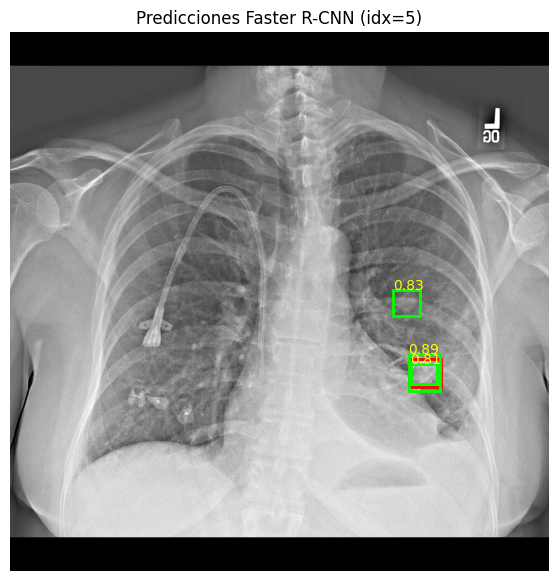

In [44]:
show_prediction_2(model, train_dataset, 5,0.8)

In [45]:
import torch

def mean_iou(model, dataset, device, score_thresh=0.5):
    model.eval()
    ious = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            img, target = dataset[idx]
            img = img.to(device)

            pred = model([img])[0]

            if len(target["boxes"]) == 0 or len(pred["boxes"]) == 0:
                continue

            scores = pred["scores"].cpu().numpy()
            boxes_pred = pred["boxes"].cpu().numpy()

            keep = scores >= score_thresh
            boxes_pred = boxes_pred[keep]

            if len(boxes_pred) == 0:
                continue

            # Para cada GT, cogemos la mejor IoU
            for gt_box in target["boxes"].numpy():
                best_iou = 0.0
                for pb in boxes_pred:
                    best_iou = max(best_iou, compute_iou(gt_box, pb))
                ious.append(best_iou)

    return np.mean(ious) if len(ious) > 0 else 0.0

In [46]:
import numpy as np

def compute_iou(boxA, boxB):
    """
    boxA, boxB: [x1, y1, x2, y2]
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = areaA + areaB - inter_area

    if union == 0:
        return 0.0

    return inter_area / union


In [34]:
#model vidn
miou = mean_iou(model, val_dataset, device)
print("Mean IoU:", miou)

Mean IoU: 0.5414162317122174


In [47]:
#model vidn best
miou = mean_iou(model, val_dataset, device)
print("Mean IoU:", miou)

Mean IoU: 0.5352652678655712


In [36]:
def collect_detections(model, dataset, device, score_thresh=0.0):
    model.eval()
    detections = []
    gt_count = 0

    with torch.no_grad():
        for idx in range(len(dataset)):
            img, target = dataset[idx]
            img = img.to(device)

            gt_boxes = target["boxes"].numpy()
            gt_count += len(gt_boxes)

            pred = model([img])[0]
            boxes = pred["boxes"].cpu().numpy()
            scores = pred["scores"].cpu().numpy()

            keep = scores >= score_thresh
            boxes = boxes[keep]
            scores = scores[keep]

            detections.append({
                "gt_boxes": gt_boxes,
                "pred_boxes": boxes,
                "scores": scores
            })

    return detections, gt_count


In [35]:
def average_precision(detections, gt_count, iou_thresh=0.5):
    preds = []

    for img_id, det in enumerate(detections):
        for box, score in zip(det["pred_boxes"], det["scores"]):
            preds.append({
                "img_id": img_id,
                "box": box,
                "score": score
            })

    # Ordenar por score descendente
    preds = sorted(preds, key=lambda x: x["score"], reverse=True)

    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))

    used_gts = {i: set() for i in range(len(detections))}

    for i, p in enumerate(preds):
        gt_boxes = detections[p["img_id"]]["gt_boxes"]
        best_iou = 0
        best_gt = -1

        for j, gt in enumerate(gt_boxes):
            if j in used_gts[p["img_id"]]:
                continue
            iou = compute_iou(p["box"], gt)
            if iou > best_iou:
                best_iou = iou
                best_gt = j

        if best_iou >= iou_thresh:
            tp[i] = 1
            used_gts[p["img_id"]].add(best_gt)
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    recall = cum_tp / (gt_count + 1e-8)
    precision = cum_tp / (cum_tp + cum_fp + 1e-8)

    # AP = área bajo la curva P–R
    #ap = np.trapz(precision, recall)
    ap = np.trapezoid(precision, recall)
    return ap


In [37]:
def map_50(model, dataset, device):
    detections, gt_count = collect_detections(model, dataset, device)
    ap50 = average_precision(detections, gt_count, iou_thresh=0.01)
    return ap50


In [38]:
#vidn
map50 = map_50(model, val_dataset, device)
print("mAP@0.5:", map50)

mAP@0.5: 0.5581965525897604


In [48]:
#vidn best
map50 = map_50(model, val_dataset, device)
print("mAP@0.5:", map50)

mAP@0.5: 0.5691306391629553
